# The theory behind the flow-field plots

*What dynamical system the "arrow" plots show, the math behind them, and why we use
them.* Based on the collective-reinforcement-learning-dynamics (CRLD) framework of
Barfuss and colleagues — see references at the end.

---

## 1. What is actually "moving"?

The arrows do **not** show agents moving in a game. They show how the agents'
**strategies change as they learn**. The object that evolves is the **joint
strategy** $X$: the probability each agent $i$ assigns to each action $a$ in each
state $s$,
$$X_i(a\mid s) \;=\; \Pr(\text{agent }i\text{ plays }a\text{ when it observes }s).$$

In the **memory-1 Iterated Prisoner's Dilemma** each agent conditions on last
round's outcome, so the states are $s\in\{cc,\,cd,\,dc,\,dd\}$. Each agent then has
4 cooperation probabilities, and the **joint strategy is an 8-dimensional vector**.

> **A single point in a flow plot = one complete joint strategy.** Our plots show a
> 2-D *slice* of that 8-D space: agent-0's $P(\text{cooperate})$ on the x-axis vs
> agent-1's on the y-axis, in one chosen state (we use the "both cooperated last
> round" state). The corners are the pure outcomes: $(0,0)$ = mutual defection,
> $(1,1)$ = mutual cooperation.

## 2. The dynamics: a deterministic learning map in strategy space

Each learning step nudges the policy in the direction of the **temporal-difference
(reward-prediction) error** $\delta$, through a softmax / replicator–mutator update:

$$
X^{t+1}_i(a\mid s)\;=\;
\frac{X^{t}_i(a\mid s)\,\exp\!\big(\alpha\,\beta\,\delta^{t}_i(s,a)\big)}
     {\sum_{b} X^{t}_i(b\mid s)\,\exp\!\big(\alpha\,\beta\,\delta^{t}_i(s,b)\big)} .
$$

- $\alpha$ — **learning rate** (step size).
- $\beta$ — **intensity of choice** / inverse temperature (exploit vs. explore).
- $\delta^{t}_i(s,a)$ — the **TD error**: how much better than expected action $a$
  in state $s$ turned out to be.

The TD error itself is

$$
\delta_i(s,a)\;=\;
\underbrace{(1-\gamma)\,\bar R_i(s,a)}_{\text{immediate reward}}
\;+\;
\underbrace{\gamma\,\overline{V}^{\,\text{next}}_i(s,a)}_{\text{discounted future}}
\;-\;
\underbrace{\tfrac{1}{\beta}\ln X_i(a\mid s)}_{\text{current estimate / baseline}},
$$

with $\gamma\in[0,1)$ the **discount factor** (how much they care about the future).
The $(1-\gamma)$ prefactor just puts immediate and future returns on the same scale.

The **strategy-averaged** reward replaces sampled experience with the *exact
expectation* under the current joint policy:

$$
\bar R_i(s,a)\;=\;\sum_{s'}\sum_{a_{-i}}
X_{-i}(s,a_{-i})\;T(s,a,a_{-i},s')\;R_i(s,a,a_{-i},s'),
$$

(summing over the other agents' actions $a_{-i}$ weighted by their policy, the
transition $T$, and the reward $R$). The successor value $\overline{V}^{\text{next}}$
is defined analogously and obtained in closed form from the Bellman equation.

> The key word is **strategy-averaged**. Because we plug in the *exact expectation*
> rather than noisy samples, the update is **deterministic** — at every strategy
> $X$ there is a single, well-defined next strategy, hence a single arrow.

## 3. What the flow field *is*

Define the one-step change

$$\Delta X \;=\; X^{t+1}-X^{t}.$$

At every point $X$ in strategy space this is a vector. The field of all these
vectors is the **flow** (the "wind"); plotting it on a grid is exactly what
`pyCRLD`'s `fp.plot_strategy_flow` does. So:

- **Each coloured arrow** = the direction (and, by colour, the strength) the
  learning rule pushes the joint policy *from that point*.
- **A purple line** = one *trajectory*: start from some strategy and follow the
  arrows. It is one run of the learning dynamics, $X^0 \to X^1 \to \dots$
- **A fixed point** ($\Delta X = 0$, where the arrows vanish) = a strategy the
  dynamics converge to — a **learned equilibrium**. The marker `x` is the start,
  `o` the converged fixed point.

This is the bridge Barfuss draws between **reinforcement learning** and
**evolutionary game theory**: the update above is a *replicator–mutator* equation,
with $\alpha\beta\,\bar q$ playing the role of "fitness".

## 4. Reading one — a live example

The cell below builds the deterministic dynamics for a single social dilemma and
draws its flow field with one trajectory overlaid.

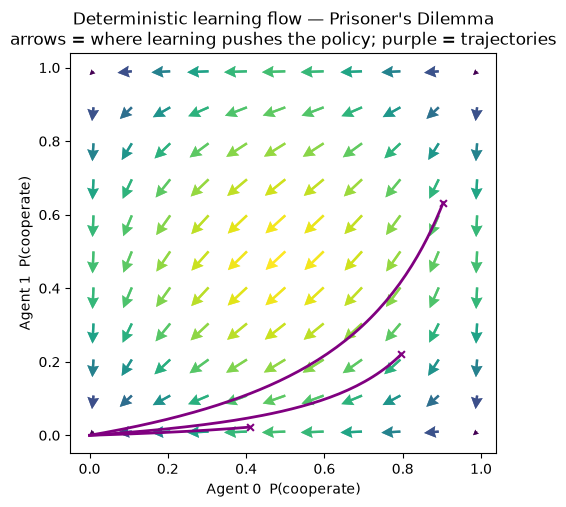

In [1]:
import os, sys
os.environ.setdefault("JAX_PLATFORMS", "cpu")       # tiny analytic compute, no GPU
sys.path.insert(0, os.path.dirname(os.getcwd()))    # repo root for pyCRLD
import numpy as np
import matplotlib.pyplot as plt
from pyCRLD.Agents.StrategyActorCritic import stratAC
from pyCRLD.Environments.SocialDilemma import SocialDilemma
from pyCRLD.Utils import FlowPlot as fp

env = SocialDilemma(R=1.0, T=1.5, S=-0.5, P=0.0)        # a Prisoner's Dilemma
mae = stratAC(env=env, learning_rates=0.1, discount_factors=0.9)
x = ([0], [0], [0]); y = ([1], [0], [0])               # agent-0 vs agent-1 P(cooperate)

fig, ax = plt.subplots(figsize=(5.5, 5.2))
fp.plot_strategy_flow(mae, x, y, use_RPEarrows=False,
                      flowarrow_points=np.linspace(0.01, 0.99, 11), axes=[ax])
for seed in range(3):
    np.random.seed(seed)
    xt, _ = mae.trajectory(mae.random_softmax_strategy(), Tmax=8000, tolerance=1e-5)
    fp.plot_trajectories([xt], x, y, cols=["purple"], axes=ax)
ax.set_xlabel("Agent 0  P(cooperate)"); ax.set_ylabel("Agent 1  P(cooperate)")
ax.set_title("Deterministic learning flow — Prisoner's Dilemma\n"
             "arrows = where learning pushes the policy; purple = trajectories")
plt.show()

Every arrow points toward the lower-left: from anywhere, the deterministic
learning dynamics drive both agents to **mutual defection $(0,0)$**. That single
picture tells you the *entire* basin structure of the game under this learner —
which is the whole point (next section).

## 5. Why we use these plots

A learning **curve** (reward vs. time) shows you *one* run from *one* start. A
**flow field** shows the rule everywhere at once, so you can read off things a curve
can't:

1. **Attractors** — where does learning end up? (the fixed points / corners).
2. **Basins of attraction** — *which* starting strategies lead to cooperation vs.
   defection, and how big each basin is. (e.g. Stag Hunt is **bistable**: two
   basins split by a separatrix.)
3. **Separatrices** — the ridge line dividing basins; it tells you how *robust*
   cooperation is to perturbation.
4. **Comparisons at a glance** — because the field is the analytic rule, we can lay
   the *same* picture side by side across **games**, **algorithms** (actor-critic
   vs. SARSA), **observability regimes**, and **player counts**, and see exactly
   which lever moves the attractor. (That is what the `flow_grids_notebook` does.)

The cost is that it requires the **analytic** dynamics object (the strategy-averaged
$\delta$), so it exists only for the small, tractable CRLD social dilemmas — not for
the sampled deep-RL runs, which only give trajectories.

## 6. The catch — and "intrinsic fluctuations"

The deterministic flow is the **infinite-batch limit**: it averages over
*infinitely many* interactions before each update, so it shows the *mean* learning
direction. Real reinforcement learning uses a **finite batch of $K$ samples**, so
each update is a **noisy** estimate of $\delta$. The actual trajectory is

$$X^{t+1} \;=\; \underbrace{\text{deterministic flow}}_{\text{the arrows}} \;+\;
\underbrace{\text{sampling noise}}_{\;\sim\, 1/\sqrt{K}\;,\ \text{vanishes as }K\to\infty}.$$

This noise is **intrinsic** — it is produced by the learning process's own finite
sampling, not added by hand. Barfuss & Meylahn (2023) show why it matters: the
deterministic IPD flow drains into the **defection** fixed point (large basin), but
the noise can **kick the trajectory across the separatrix** into the **cooperation**
basin (win-stay–lose-shift / tit-for-tat is also a stable fixed point). Because the
cooperative fixed point is "stickier" once reached, the system spends more time
there — and intrinsic fluctuations **roughly double the cooperation rate (up to
~80%)**, on top of a high discount $\gamma$, low exploration, and small $\alpha$.

> **So how to read our defection-bound flow plots:** they show the *deterministic
> skeleton* of the dynamics (the average pull, often toward defection). The
> fluctuations a real learner experiences ride on top of that skeleton and can lift
> cooperation well above what the bare flow predicts. This is also why our
> finite-batch deep-RL value learner (IQL) cooperated (~0.95) while the
> deterministic actor-critic flow defects — fluctuations + value bootstrapping,
> exactly as the paper describes.

## References

- W. Barfuss, J. M. Meylahn. **Intrinsic fluctuations of reinforcement learning
  promote cooperation.** *Scientific Reports* 13, 1309 (2023).
  [open access (PMC)](https://pmc.ncbi.nlm.nih.gov/articles/PMC9873645/)
- W. Barfuss. **Dynamical systems as a level of cognitive analysis of multi-agent
  learning.** *Neural Computing and Applications* 34, 1653–1671 (2022).
  [open access (PMC)](https://pmc.ncbi.nlm.nih.gov/articles/PMC8827307/)
- W. Barfuss, J. F. Donges, J. Kurths. **Deterministic limit of temporal difference
  reinforcement learning for stochastic games.** *Physical Review E* 99, 043305 (2019).
- W. Barfuss. **pyCRLD** — Collective Reinforcement Learning Dynamics in Python.
  <https://wbarfuss.github.io/pyCRLD/>